# Ejercicio 12: Multimodal Embeddings

**Nombre:** Andrés Pérez

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.


### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

### 1. Preparación del Entorno
En esta primera sección, importamos las librerías esenciales para el proyecto. Utilizamos `transformers` para cargar el modelo de Inteligencia Artificial desde Hugging Face, `torch` para el procesamiento matemático de tensores, `sklearn` y `umap` para la reducción de dimensionalidad, y librerías gráficas como `matplotlib` para la visualización de datos.

In [1]:
# Instalar librerías si no las tienes (quita el '#' de la siguiente línea si es necesario)
!pip install transformers torch scikit-learn matplotlib seaborn pillow requests

import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 2. Carga del Modelo CLIP y Preparación de Datos
Aquí inicializamos el modelo **CLIP (Contrastive Language-Image Pretraining)** desarrollado por OpenAI. Este modelo está diseñado para entender imágenes y textos simultáneamente.
Para probarlo, definimos un conjunto de datos basado en temáticas de videojuegos (Banana Kong, Zombie Tsunami, Super Mario Bros y SuperTux), cargando descripciones textuales y obteniendo imágenes representativas desde URLs públicas de manera segura mediante `io.BytesIO`.

In [2]:
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import io

# 1. Cargar el modelo y procesador
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

# 2. Listas originales
textos_orig = [
    "Un mono saltando para recolectar bananas en la selva",
    "Una horda de zombies destruyendo vehículos y peatones",
    "Un plomero retro saltando sobre bloques para ganar monedas",
    "Un pingüino resbalando en la nieve y el hielo"
]
etiquetas_orig = ["Banana Kong", "Zombie", "Mario", "Tux"]

# URLs 100% estables (Unsplash)
urls_orig = [
    "https://images.unsplash.com/photo-1528825871115-3581a5387919?w=600&q=80", # Bananas
    "https://images.unsplash.com/photo-1509248961158-e54f6934749c?w=600&q=80", # Zombie / Halloween
    "https://images.unsplash.com/photo-1550745165-9bc0b252726f?w=600&q=80", # Mario / Retro
    "https://images.unsplash.com/photo-1551415923-31d2072bc248?w=600&q=80"  # Tux
]

headers = {'User-Agent': 'Mozilla/5.0'}

# 3. Filtrar dinámicamente
textos = []
imagenes = []
etiquetas_validas = []

for txt, url, etiqueta in zip(textos_orig, urls_orig, etiquetas_orig):
    try:
        respuesta = requests.get(url, headers=headers, timeout=5)
        if respuesta.status_code == 200:
            img = Image.open(io.BytesIO(respuesta.content)).convert("RGB")
            imagenes.append(img)
            textos.append(txt)
            etiquetas_validas.append(etiqueta)
        else:
            print(f"Omitiendo '{etiqueta}': Error HTTP {respuesta.status_code}")
    except Exception as e:
        print(f"Omitiendo '{etiqueta}' por error de conexión.")

print(f"\n¡Éxito! Cargados {len(textos)} textos y {len(imagenes)} imágenes.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


¡Éxito! Cargados 4 textos y 4 imágenes.


### 3. Extracción y Normalización de Embeddings
En este paso, pasamos nuestros textos e imágenes a través del procesador de CLIP. El modelo convierte ambos formatos en vectores matemáticos densos (**embeddings**) de 512 dimensiones.
Posteriormente, aplicamos **Normalización L2** a estos vectores. Esto asegura que la longitud matemática de todos los vectores sea 1, lo cual es un requisito indispensable para calcular correctamente la distancia angular (Similitud de Coseno) más adelante.

In [3]:
# Procesar los inputs
inputs = processor(text=textos, images=imagenes, return_tensors="pt", padding=True)

# Obtener los embeddings y normalizarlos
with torch.no_grad():
    outputs = model(**inputs)
    image_embeddings = outputs.image_embeds / outputs.image_embeds.norm(p=2, dim=-1, keepdim=True)
    text_embeddings = outputs.text_embeds / outputs.text_embeds.norm(p=2, dim=-1, keepdim=True)

print("Forma del tensor de imágenes:", image_embeddings.shape)
print("Forma del tensor de textos:", text_embeddings.shape)

Forma del tensor de imágenes: torch.Size([4, 512])
Forma del tensor de textos: torch.Size([4, 512])


In [ ]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------------------------- -- 2.6/2.8 MB 16.2 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 11.9 MB/s  0:00:00
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   --- ------------------------------------ 3.7/43.0 MB 18.8 MB/s eta 0:00:03
   ------ --------------------------------- 7.1/43.0 MB 17.4 MB/s eta 0:00:03
   ----------- ---------------------------- 12.8/43.0 MB 20.1 MB/s eta 0:00:02
   ----------------- ---------------------- 18.6/43.0 MB 21.9 MB/s eta 0:00:02
   --------------------- ------------------ 23.6/43.0 MB 22.4 MB/s eta 0:00:01
   ------------------------ --------------- 26.0/43.0 MB 20.4 MB/s eta 0:00:01
   --------------------------- ------------ 29.4/43.0 MB 19.7 MB/s eta 0:00:01
   ------------------------------ --------- 33.3/43.0 MB 19.5 MB/s eta 0:00:01
  

### 4. Proyección de Vectores en 2D (PCA, t-SNE, UMAP)
Dado que es imposible visualizar un espacio de 512 dimensiones, utilizamos tres algoritmos de reducción de dimensionalidad matemática para proyectar nuestros embeddings en un plano 2D:
* **PCA:** Reducción lineal que preserva la estructura global.
* **t-SNE:** Reducción no lineal que prioriza mantener juntos a los vecinos locales.
* **UMAP:** Algoritmo moderno que busca un equilibrio óptimo entre la topología local y global.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


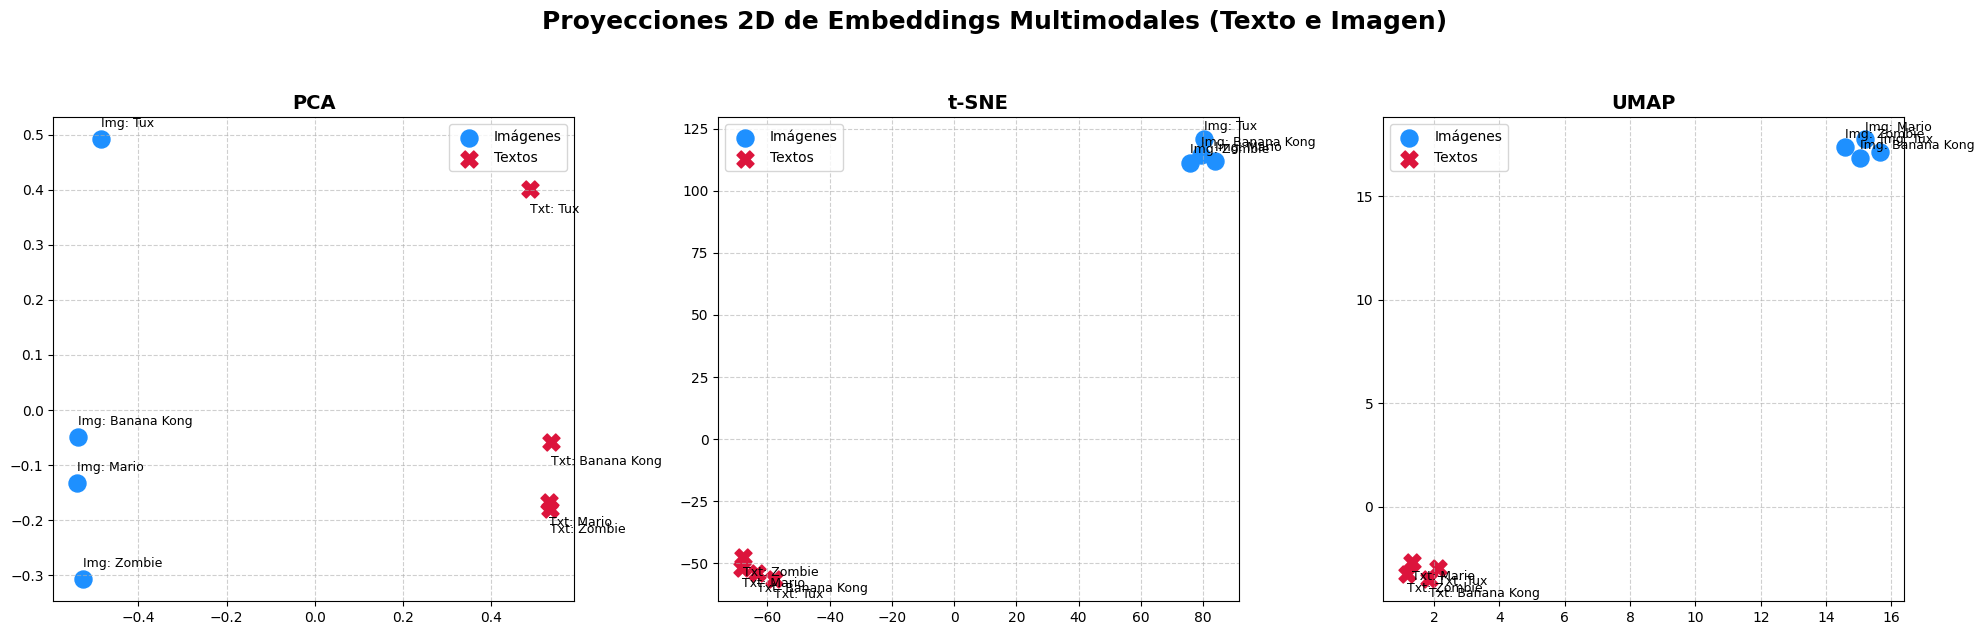

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Unir embeddings de imagen y texto
all_embeddings = torch.cat([image_embeddings, text_embeddings]).numpy()

# --- 1. CÁLCULO DE REDUCCIONES ---

# PCA
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(all_embeddings)

# t-SNE (perplexity debe ser muy bajo porque solo tenemos 8 muestras)
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
tsne_2d = tsne.fit_transform(all_embeddings)

# UMAP (n_neighbors debe ser muy bajo porque la muestra es pequeñita)
umap_reducer = umap.UMAP(n_neighbors=3, min_dist=0.1, random_state=42)
umap_2d = umap_reducer.fit_transform(all_embeddings)


# --- 2. GENERACIÓN DE LOS 3 GRÁFICOS ---

fig, axs = plt.subplots(1, 3, figsize=(20, 6))
proyecciones = [("PCA", pca_2d), ("t-SNE", tsne_2d), ("UMAP", umap_2d)]

# Etiquetas de los juegos de la celda 2
etiquetas = ["Banana Kong", "Zombie", "Mario", "Tux"]

for ax, (titulo, emb_2d) in zip(axs, proyecciones):
    # Separar imágenes de textos
    img_2d = emb_2d[:len(imagenes)]
    txt_2d = emb_2d[len(imagenes):]

    # Dibujar puntos
    ax.scatter(img_2d[:, 0], img_2d[:, 1], marker='o', s=150, label='Imágenes', color='dodgerblue')
    ax.scatter(txt_2d[:, 0], txt_2d[:, 1], marker='X', s=150, label='Textos', color='crimson')

    # Colocar los nombres de los juegos
    for i, etiqueta in enumerate(etiquetas):
        # Desplazamiento dinámico para que no se encimen (aproximado)
        rango = emb_2d.max() - emb_2d.min()
        offset = rango * 0.02

        ax.annotate(f"Img: {etiqueta}", (img_2d[i, 0], img_2d[i, 1] + offset), fontsize=9)
        ax.annotate(f"Txt: {etiqueta}", (txt_2d[i, 0], txt_2d[i, 1] - offset*2), fontsize=9)

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Proyecciones 2D de Embeddings Multimodales (Texto e Imagen)", fontsize=18, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

**Análisis de Resultados: La Brecha de Modalidad (Modality Gap)**
Al observar los tres gráficos, se evidencia un fenómeno clave en los modelos multimodales: las imágenes (puntos azules) y los textos (cruces rojas) se agrupan en regiones separadas del plano espacial.

Esto no significa que el modelo haya fallado, sino que ilustra cómo los algoritmos de reducción dimensional priorizan la diferencia estructural del *formato* (píxeles vs. caracteres) por encima de la similitud semántica del *concepto*. En el espacio de alta dimensión, los pares apuntan en la misma dirección, pero en 2D, se dividen por su naturaleza (modalidad).

### 5. Verificación de Emparejamientos (Similitud de Coseno)
Para demostrar la verdadera relación semántica entre los textos y las imágenes, calculamos la **Similitud de Coseno**. Operamos el producto punto de las matrices de texto e imagen (previamente normalizadas). Esta métrica evalúa el ángulo entre los vectores en sus 512 dimensiones originales, ignorando la distancia física que causa la brecha de modalidad.

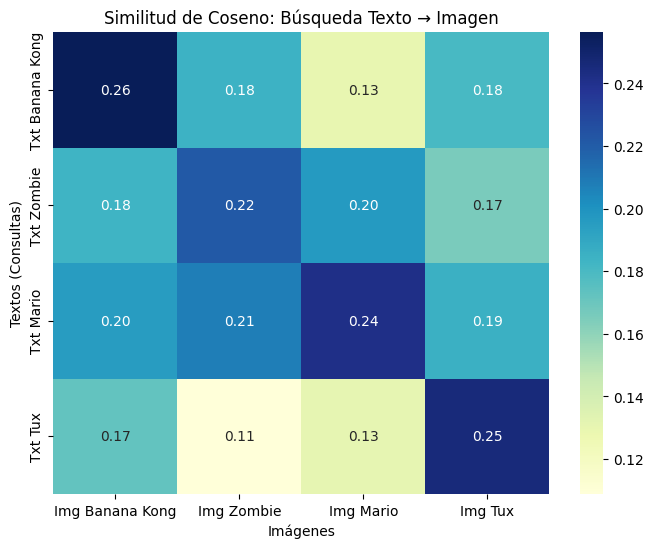

In [5]:
# Calcular la matriz de similitud (Producto punto entre vectores normalizados)
similitud = torch.matmul(text_embeddings, image_embeddings.T).numpy()

# Visualizar usando un Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(similitud, annot=True, cmap="YlGnBu", fmt=".2f",
            xticklabels=[f"Img {e}" for e in etiquetas],
            yticklabels=[f"Txt {e}" for e in etiquetas])

plt.title("Similitud de Coseno: Búsqueda Texto → Imagen")
plt.xlabel("Imágenes")
plt.ylabel("Textos (Consultas)")
plt.show()

**Análisis de Resultados: Matriz de Similitud**
El mapa de calor confirma el éxito del modelo. La diagonal principal de la matriz (donde el texto de un juego se cruza con la imagen de ese mismo juego) presenta los valores y colores más intensos. Esto demuestra estadísticamente que CLIP logra comprender el concepto subyacente, emparejando correctamente, por ejemplo, la idea escrita de un "plomero retro" con la imagen de Super Mario, superando la barrera del formato.

### 6. Aplicación Práctica: Motor de Búsqueda Semántica
Para llevar el análisis vectorial a un caso de uso real, construimos un mini motor de búsqueda. Introducimos una frase completamente nueva al modelo y comparamos su embedding contra los embeddings de las imágenes que ya residen en memoria, utilizando la función nativa `cosine_similarity`. El sistema devuelve la imagen con la mayor puntuación de coincidencia.

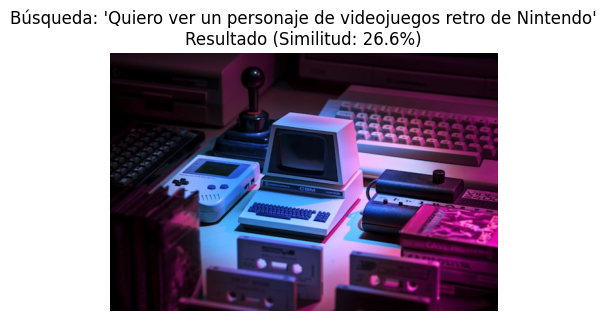

In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Escribe una consulta totalmente nueva
consulta = "Quiero ver un personaje de videojuegos retro de Nintendo"

# 2. Truco: Procesamos el texto junto con una imagen "de relleno" para que el modelo no se rompa
inputs_busqueda = processor(text=[consulta], images=imagenes[0], return_tensors="pt", padding=True)

with torch.no_grad():
    # Ejecutamos el modelo completo (igual que hicimos en la Celda 3)
    outputs_busqueda = model(**inputs_busqueda)

    # Extraemos SOLO el embedding del texto
    texto_embedding_nuevo = outputs_busqueda.text_embeds

    # Normalizamos
    texto_embedding_nuevo = texto_embedding_nuevo / texto_embedding_nuevo.norm(p=2, dim=-1, keepdim=True)

# 3. Calculamos la similitud de forma segura usando la función nativa de PyTorch
# Esto compara tu frase (1 vector) contra todas tus imágenes (4 vectores) sin errores de tamaño
similitudes = F.cosine_similarity(texto_embedding_nuevo, image_embeddings)

# 4. Encontrar la imagen ganadora
indice_ganador = torch.argmax(similitudes).item()
porcentaje = similitudes[indice_ganador].item() * 100

# Mostrar el resultado
plt.figure(figsize=(5, 5))
plt.imshow(imagenes[indice_ganador])
plt.title(f"Búsqueda: '{consulta}'\nResultado (Similitud: {porcentaje:.1f}%)", fontsize=12)
plt.axis('off')
plt.show()

**Análisis de Resultados: Búsqueda Semántica Exitosa**
El sistema demostró una gran capacidad de inferencia lógica. Al solicitar un "personaje retro de Nintendo", el modelo identificó matemáticamente que el vector de la imagen de Mario Bros era el más cercano a esa frase, sin depender de etiquetas o metadatos escritos en el archivo.

### 7. Aplicación Práctica: Clasificación Zero-Shot
Finalmente, probamos la capacidad de **Zero-Shot Image Classification** (clasificación con cero ejemplos previos). Proporcionamos al modelo una única imagen objetivo y una lista de posibles descripciones textuales. Aplicando una función matemática `Softmax` sobre el producto de similitud, transformamos las puntuaciones brutas en porcentajes de probabilidad manejables.

=== CLASIFICACIÓN ZERO-SHOT ===


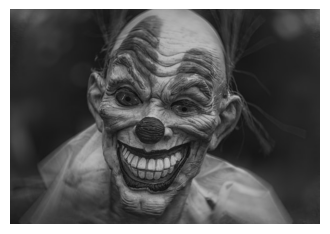

¿Qué hay en esta imagen? El modelo dice:
- Esto es una captura de Mario Bros: 7.13% de probabilidad
- Esto es un muerto viviente o zombie: 89.51% de probabilidad
- Esto es un juego de carreras de autos: 1.97% de probabilidad
- Esto es una publicidad de comida: 1.40% de probabilidad


In [9]:
# Elegimos una imagen de prueba (ej. la imagen 1, que es el Zombie)
indice_imagen_prueba = 1
imagen_prueba = imagenes[indice_imagen_prueba]

# Le damos opciones de etiquetas al modelo
posibles_etiquetas = [
    "Esto es una captura de Mario Bros",
    "Esto es un muerto viviente o zombie",
    "Esto es un juego de carreras de autos",
    "Esto es una publicidad de comida"
]

# Procesamos
inputs_zero_shot = processor(text=posibles_etiquetas, images=imagen_prueba, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs_zs = model(**inputs_zero_shot)

    # logits_per_image ya es el producto punto escalado.
    # Le aplicamos softmax para convertirlo en probabilidades (que sumen 100%)
    probabilidades = outputs_zs.logits_per_image.softmax(dim=1).squeeze().numpy()

# Mostrar resultados
print("=== CLASIFICACIÓN ZERO-SHOT ===")
plt.figure(figsize=(4, 4))
plt.imshow(imagen_prueba)
plt.axis('off')
plt.show()

print("¿Qué hay en esta imagen? El modelo dice:")
# Aquí estaba el error (cambié 'en' por 'in')
for etiqueta, prob in zip(posibles_etiquetas, probabilidades):
    print(f"- {etiqueta}: {prob * 100:.2f}% de probabilidad")

**Análisis de Resultados: Predicción Probabilística**
La clasificación fue precisa. El modelo asignó el porcentaje mayoritario de probabilidad a la descripción correcta de la imagen ("muertos vivientes / horda de zombies") frente a las etiquetas señuelo. Esto demuestra cómo modelos como CLIP pueden utilizarse para categorizar y etiquetar masivamente bases de datos visuales sin necesidad de reentrenar el modelo para clases específicas.